# Examples of computing the lattice diameter

This notebook computes the lattice diameter of some polytopes. Run it with a SageMath kernel.

In [1]:
from sage.all import QQ, matrix, vector
from algorithm_2d_edge_opposite_vertex import (lattice_diameter_2d, lattice_diameter_2d_all_directions)
from algorithm_general_dimension import (lattice_diameter_ILP, lattice_diameter_ILP_by_vertices)
from plotting import plot_lattice_diameter

## Lattice polygons

The two-dimensional algorithm accepts a list of integral points whose convex hull is the polygon.

Lattice diameter: 3
A lattice diameter segment: ((-1, -2), (-1, 1))
Segments representing all lattice diameter directions: [((-1, -2), (-1, 1)), ((1, -2), (-2, 1)), ((0, 1), (0, -2)), ((-3, 0), (0, 0))]


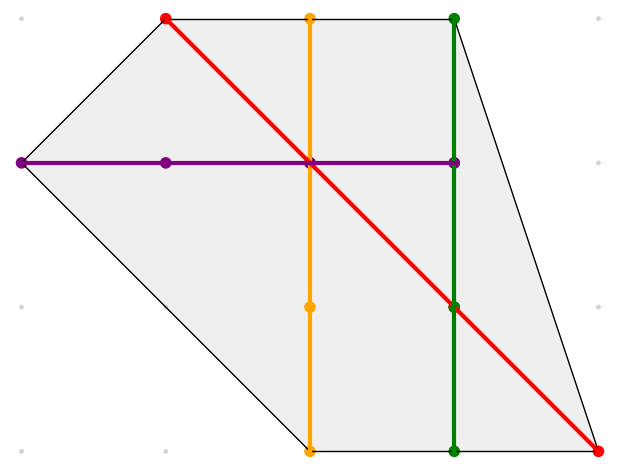

In [2]:
#vertices = [(0, 0), (-2, 4), (2, 6), (3, 4), (1, -2)]
vertices = [(0, 1), (1, -2), (-1, -2), (-3, 0), (-2, 1)]


ld, ld_seg = lattice_diameter_2d(vertices)
ld, ld_segs = lattice_diameter_2d_all_directions(vertices)

print("Lattice diameter:", ld)
print("A lattice diameter segment:", ld_seg)
print("Segments representing all lattice diameter directions:", ld_segs)

plot_lattice_diameter(ld_segs, vertices)

## Three-dimensional rational polytope given by inequalities

In [3]:
A = matrix(QQ, [[1, -QQ(1)/6, QQ(1)/6], [-QQ(3)/2, QQ(1)/5, 0], [QQ(1)/8, 1, 0], [0, -QQ(3)/2, 0], [0, QQ(1)/5, 1], [QQ(1)/8, QQ(1)/8, -1], [1, 1, 1]])
b = vector(QQ, [QQ(5)/2, QQ(3)/2, QQ(1)/2, QQ(1)/2, QQ(1)/2, QQ(4)/5, QQ(8)/4])

ld, ld_seg = lattice_diameter_ILP(A, b)

print("Lattice diameter:", ld)
print("A lattice diameter segment:", ld_seg)

Lattice diameter: 3
A lattice diameter segment: ((-1, 0, 0), (2, 0, 0))


In [4]:
G = plot_lattice_diameter([ld_seg], A=A, b=b)
G.show(viewer="threejs", online=True) 
#G.show(viewer="tachyon", aspect_ratio=1)

Graphics3d Object

## Three-dimensional lattice polytope with interior lattice diameter segment

In [5]:
vertices = [(5, 1, 0), (5, 0, 1), (4, -1, -1), (-4, -1, 0), (-4, 0, -1), (-5, 1, 1)]

ld, ld_seg = lattice_diameter_ILP_by_vertices(vertices)

print("Lattice diameter:", ld)
print("A lattice-diameter segment:", ld_seg)

G = plot_lattice_diameter([ld_seg], vertices=vertices)
G.show(viewer="threejs", online=True)
#G.show(viewer="tachyon", aspect_ratio=1)

Lattice diameter: 8
A lattice-diameter segment: ((-4, 0, 0), (4, 0, 0))


Graphics3d Object

## Statistic of lattice diameters of lattice polygons with N lattice points for fixed N

In `lattice_polygons_by_N.json` we have collected all lattice polygons (up to affine unimodular equivalence) with up to $N=15$ lattice points. These are taken from the Bohnert-Springer database [https://doi.org/10.5281/zenodo.13959996](https://doi.org/10.5281/zenodo.13959996).

Choose some value for $N= \ldots $ in the code below, for $3 \leq N \leq 15$ and see the distribution of lattice diameters.

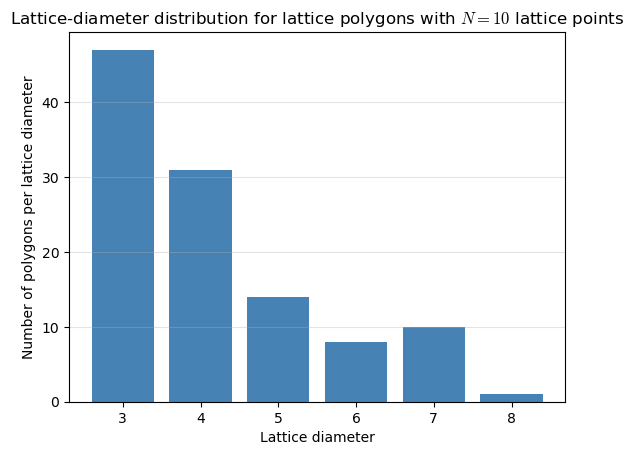

Computed 111 polygons with N = 10.


In [57]:
import json
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt

#Choose N here
N = 10

data = json.loads(Path("lattice_polygons_by_N.json").read_text())

polygons = [
    [tuple(vertex) for vertex in record["vertices"]]
    for record in data["polygons"] if record["N"] == N
]

diameters = [ int(lattice_diameter_2d(vertices)[0]) for vertices in polygons ]

counts = Counter(diameters)
L_values = sorted(counts)

#plt.figure(figsize=(6, 4))
plt.xticks(L_values)
plt.xlabel("Lattice diameter")
plt.ylabel("Number of polygons per lattice diameter")
plt.title(f"Lattice-diameter distribution for lattice polygons with $N = {N}$ lattice points")
plt.grid(axis="y", alpha=0.35)
plt.bar(L_values, [counts[L] for L in L_values], color="steelblue")
plt.show()

print(f"Computed {len(polygons)} polygons with N = {N}.")